## COVID Drivers: Modeling

### Table of Contents
* [Read the Data](#read)</BR>
* [Time Series Decomposition](#decomp)</BR>



Import packages

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import os
import ruptures as rpt
import altair as alt

import statsmodels.api as sm

In [2]:
# Import project specific utilities
from utils.functions import *

In [15]:
path_in = 'data/ready/'
flags_in = 'by_dates.csv'
full_in = 'full_dataset.csv'

### <a id='read'>Read the data</a>

Read dataset created in covid_drivers_05_Prep.ipynb

In [16]:
df_init = pd.read_csv(path_in + flags_in, low_memory=False)

In [17]:
df_init.head()

,CRASH_DATE,AGGRESSIVE_DRIVING,NHTSA_AGG_DRIVING,NO_CLEARANCE,RUNNING_RED_LT,RUNNING_STOP_SIGN,SPEEDING,SPEEDING_RELATED,TAILGATING,POST_COVID
0,2005-01-01,1,0,0,0,0,0,1,0,0
1,2005-01-01,1,0,0,0,0,0,1,0,0
2,2005-01-01,1,0,0,0,0,1,1,0,0
3,2005-01-01,1,0,1,0,0,0,0,0,0
4,2005-01-01,0,0,0,0,0,0,0,0,0


In [18]:
df_init.info()

<class 'pandas.DataFrame'>
RangeIndex: 2460484 entries, 0 to 2460483
Data columns (total 10 columns):
 #   Column              Dtype
---  ------              -----
 0   CRASH_DATE          str  
 1   AGGRESSIVE_DRIVING  int64
 2   NHTSA_AGG_DRIVING   int64
 3   NO_CLEARANCE        int64
 4   RUNNING_RED_LT      int64
 5   RUNNING_STOP_SIGN   int64
 6   SPEEDING            int64
 7   SPEEDING_RELATED    int64
 8   TAILGATING          int64
 9   POST_COVID          int64
dtypes: int64(9), str(1)
memory usage: 187.7 MB


In [19]:
df_init['CRASH_DATE'] = pd.to_datetime(df_init['CRASH_DATE'])

In [20]:
summ_idx = df_init.copy().set_index('CRASH_DATE')

In [21]:
summ_idx.head()

,AGGRESSIVE_DRIVING,NHTSA_AGG_DRIVING,NO_CLEARANCE,RUNNING_RED_LT,RUNNING_STOP_SIGN,SPEEDING,SPEEDING_RELATED,TAILGATING,POST_COVID
CRASH_DATE,,,,,,,,,
2005-01-01,1,0,0,0,0,0,1,0,0
2005-01-01,1,0,0,0,0,0,1,0,0
2005-01-01,1,0,0,0,0,1,1,0,0
2005-01-01,1,0,1,0,0,0,0,0,0
2005-01-01,0,0,0,0,0,0,0,0,0


In [22]:
summ_by_date = summ_idx.copy().resample('MS').mean()

In [23]:
cols = ['AGGRESSIVE_DRIVING',
 'NHTSA_AGG_DRIVING',
 'NO_CLEARANCE',
 'RUNNING_RED_LT',
 'RUNNING_STOP_SIGN',
 'SPEEDING',
 'SPEEDING_RELATED',
 'TAILGATING']

### <a id='decomp'>Time Series Decomposition</a>

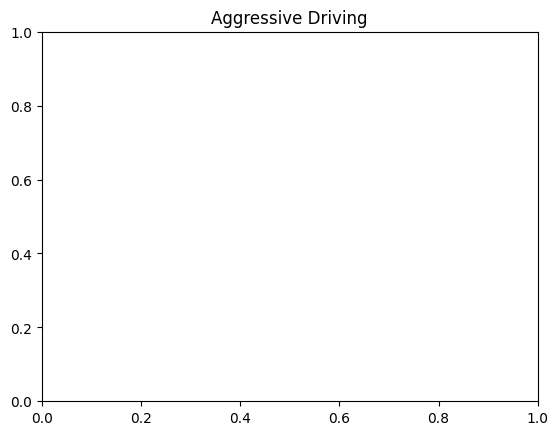

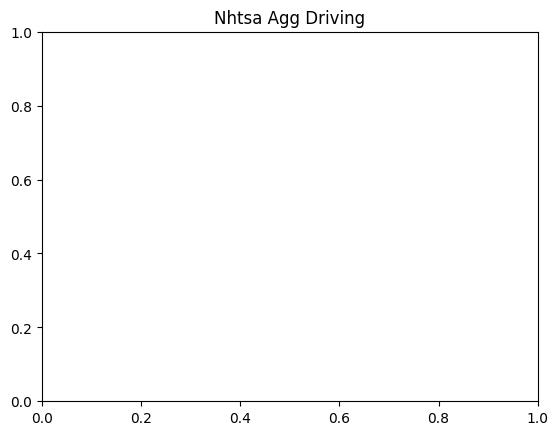

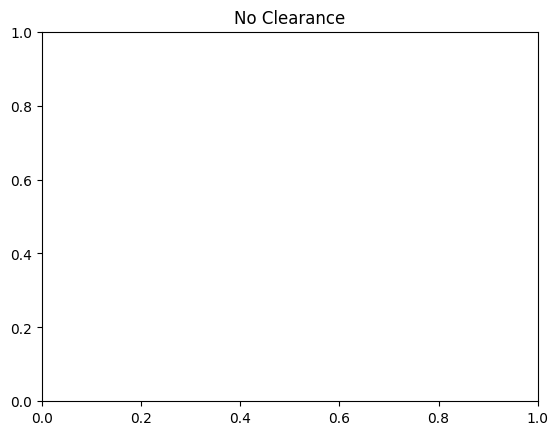

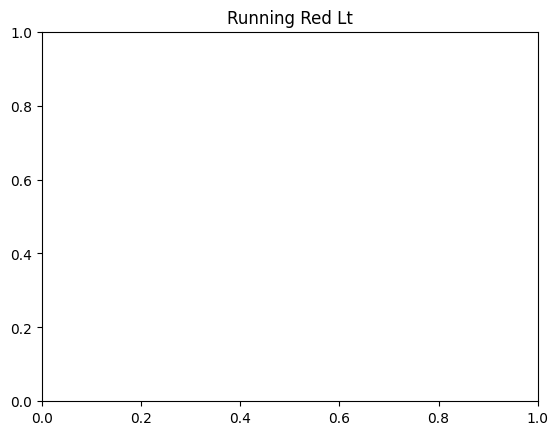

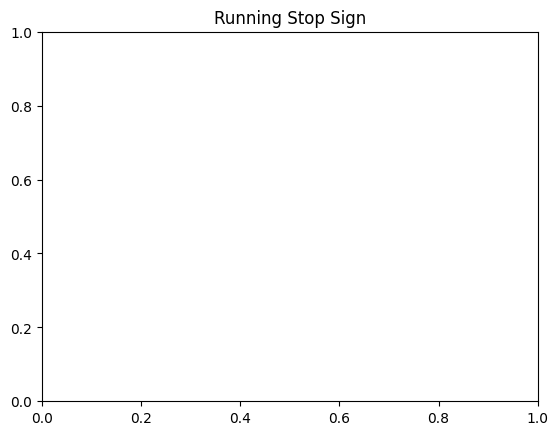

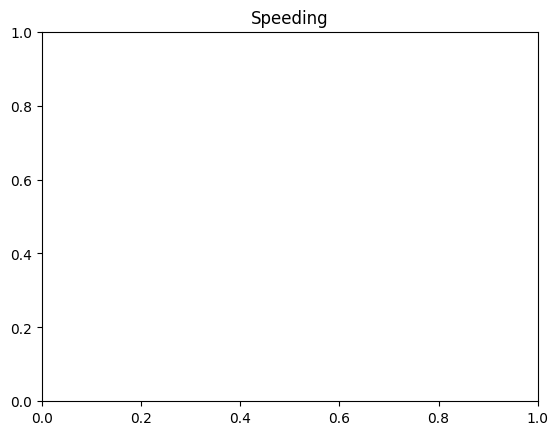

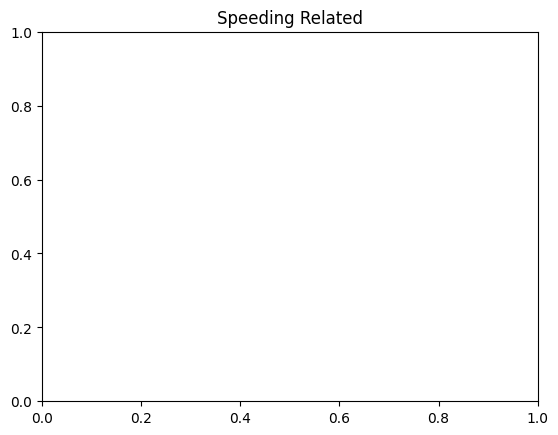

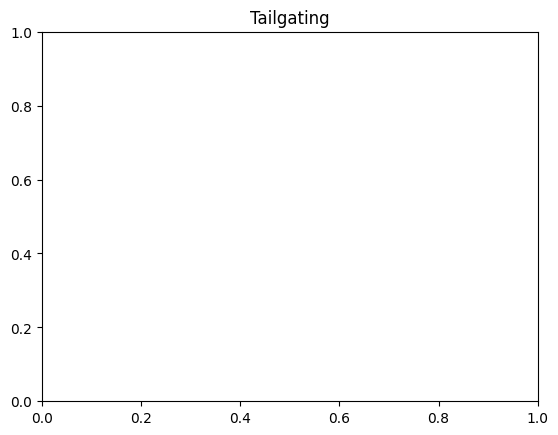

In [ ]:
for c in cols:
    ready_series = summ_by_date.loc[:,[c]].copy()

    my_decomposition = sm.tsa.seasonal_decompose(ready_series, model='additive')

    

    plt.title(c.replace('_',' ').title())
    plt.show()